In [1]:
!pip install torchprofile


In [2]:
import copy
import math
import random
import time
from collections import OrderedDict, defaultdict
from typing import Union, List

import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import nn
from torch.optim import *
from torch.optim.lr_scheduler import *
from torch.utils.data import DataLoader
from torchprofile import profile_macs
from torchvision.datasets import *
from torchvision.transforms import *
from tqdm.auto import tqdm

from torchprofile import profile_macs

assert torch.cuda.is_available(), \
"The current runtime does not have CUDA support." \
"Please go to menu bar (Runtime - Change runtime type) and select GPU"

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [5]:
def download_url(url, model_dir='.', overwrite=False):
    import os, sys, ssl
    from urllib.request import urlretrieve
    ssl._create_default_https_context = ssl._create_unverified_context
    target_dir = url.split('/')[-1]
    model_dir = os.path.expanduser(model_dir)
    try:
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)
        model_dir = os.path.join(model_dir, target_dir)
        cached_file = model_dir
        if not os.path.exists(cached_file) or overwrite:
            sys.stderr.write('Downloading: "{}" to {}\n'.format(url, cached_file))
            urlretrieve(url, cached_file)
        return cached_file
    except Exception as e:
        # remove lock file so download can be executed next time.
        os.remove(os.path.join(model_dir, 'download.lock'))
        sys.stderr.write('Failed to download from url %s' % url + '\n' + str(e) + '\n')
        return None

In [6]:
def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class RESNET(nn.Module):
    def __init__(self, block=BasicBlock, layers=[2, 2, 2, 2], num_classes=1000):
        super(RESNET, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [7]:
# ============================================================
# CHECKPOINT UTILITIES
# ============================================================

import os
import torch

# Folder in Google Drive where checkpoints will be stored
CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch,
    loss,
    filename="checkpoint.pt"
):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "loss": loss,
    }, checkpoint_path)

    print(f"Checkpoint saved to: {checkpoint_path}")


def load_checkpoint(
    model,
    optimizer=None,
    scheduler=None,
    filename="checkpoint.pt",
    device="cuda"
):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint["scheduler_state_dict"] is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    loss = checkpoint["loss"]

    print(f"Loaded checkpoint from: {checkpoint_path}")
    print(f"Resuming from epoch {start_epoch}")

    return start_epoch, loss

In [8]:
def train(
  model: nn.Module,
  dataloader: DataLoader,
  criterion: nn.Module,
  optimizer: Optimizer,
  scheduler: LambdaLR,
  callbacks = None
) -> None:
  model.train()

  for inputs, targets in tqdm(dataloader, desc='train', leave=False):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Reset the gradients (from the last iteration)
    optimizer.zero_grad()

    # Forward inference
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward propagation
    loss.backward()

    # Update optimizer and LR scheduler
    optimizer.step()
    scheduler.step()

    if callbacks is not None:
        for callback in callbacks:
            callback()

In [9]:
@torch.inference_mode()
def evaluate(
  model: nn.Module,
  dataloader: DataLoader,
  verbose=True,
) -> float:
  model.eval()

  num_samples = 0
  num_correct = 0

  for inputs, targets in tqdm(dataloader, desc="eval", leave=False,
                              disable=not verbose):
    # Move the data from CPU to GPU
    inputs = inputs.cuda()
    targets = targets.cuda()

    # Inference
    outputs = model(inputs)

    # Convert logits to class indices
    outputs = outputs.argmax(dim=1)

    # Update metrics
    num_samples += targets.size(0)
    num_correct += (outputs == targets).sum()

  return (num_correct / num_samples * 100).item()

In [10]:
def get_model_macs(model, inputs) -> int:
    return profile_macs(model, inputs)


def get_sparsity(tensor: torch.Tensor) -> float:
    """
    calculate the sparsity of the given tensor
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    return 1 - float(tensor.count_nonzero()) / tensor.numel()


def get_model_sparsity(model: nn.Module) -> float:
    """
    calculate the sparsity of the given model
        sparsity = #zeros / #elements = 1 - #nonzeros / #elements
    """
    num_nonzeros, num_elements = 0, 0
    for param in model.parameters():
        num_nonzeros += param.count_nonzero()
        num_elements += param.numel()
    return 1 - float(num_nonzeros) / num_elements

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
            num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

In [11]:
def test_fine_grained_prune(
    test_tensor=torch.tensor([[-0.46, -0.40, 0.39, 0.19, 0.37],
                              [0.00, 0.40, 0.17, -0.15, 0.16],
                              [-0.20, -0.23, 0.36, 0.25, 0.03],
                              [0.24, 0.41, 0.07, 0.13, -0.15],
                              [0.48, -0.09, -0.36, 0.12, 0.45]]),
    test_mask=torch.tensor([[True, True, False, False, False],
                            [False, True, False, False, False],
                            [False, False, False, False, False],
                            [False, True, False, False, False],
                            [True, False, False, False, True]]),
    target_sparsity=0.75, target_nonzeros=None):
    def plot_matrix(tensor, ax, title):
        ax.imshow(tensor.cpu().numpy() == 0, vmin=0, vmax=1, cmap='tab20c')
        ax.set_title(title)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        for i in range(tensor.shape[1]):
            for j in range(tensor.shape[0]):
                text = ax.text(j, i, f'{tensor[i, j].item():.2f}',
                                ha="center", va="center", color="k")

    test_tensor = test_tensor.clone()
    fig, axes = plt.subplots(1,2, figsize=(6, 10))
    ax_left, ax_right = axes.ravel()
    plot_matrix(test_tensor, ax_left, 'dense tensor')

    sparsity_before_pruning = get_sparsity(test_tensor)
    mask = fine_grained_prune(test_tensor, target_sparsity)
    sparsity_after_pruning = get_sparsity(test_tensor)
    sparsity_of_mask = get_sparsity(mask)

    plot_matrix(test_tensor, ax_right, 'sparse tensor')
    fig.tight_layout()
    plt.show()

    print('* Test fine_grained_prune()')
    print(f'    target sparsity: {target_sparsity:.2f}')
    print(f'        sparsity before pruning: {sparsity_before_pruning:.2f}')
    print(f'        sparsity after pruning: {sparsity_after_pruning:.2f}')
    print(f'        sparsity of pruning mask: {sparsity_of_mask:.2f}')

    if target_nonzeros is None:
        if test_mask.equal(mask):
            print('* Test passed.')
        else:
            print('* Test failed.')
    else:
        if mask.count_nonzero() == target_nonzeros:
            print('* Test passed.')
        else:
            print('* Test failed.')

In [12]:
checkpoint_url = "https://huggingface.co/microsoft/resnet-18/resolve/main/pytorch_model.bin"
checkpoint_path = download_url(checkpoint_url)
checkpoint = torch.load(checkpoint_path, map_location="cuda")

# Create a mapping from HF keys to our model keys
def remap_keys(state_dict):
    new_dict = {}
    for k, v in state_dict.items():
        # Remove prefix
        new_k = k.replace("resnet.", "")
        # Map embedder to initial layers
        new_k = new_k.replace("embedder.embedder.convolution", "conv1")
        new_k = new_k.replace("embedder.embedder.normalization", "bn1")
        # Map stages to layers
        for i in range(4):
            new_k = new_k.replace(f"encoder.stages.{i}.layers", f"layer{i+1}")
        # Map internal block components
        new_k = new_k.replace("layer.0.convolution", "conv1")
        new_k = new_k.replace("layer.0.normalization", "bn1")
        new_k = new_k.replace("layer.1.convolution", "conv2")
        new_k = new_k.replace("layer.1.normalization", "bn2")
        new_k = new_k.replace("shortcut.convolution", "downsample.0")
        new_k = new_k.replace("shortcut.normalization", "downsample.1")
        # Map head
        new_k = new_k.replace("classifier", "fc")

        new_dict[new_k] = v
    return new_dict

model = RESNET().cuda()
mapped_checkpoint = remap_keys(checkpoint)

# Filter out num_batches_tracked if present
mapped_checkpoint = {k: v for k, v in mapped_checkpoint.items() if "num_batches_tracked" not in k}

model.load_state_dict(mapped_checkpoint, strict=False)

print(f"Successfully loaded and remapped checkpoint from {checkpoint_url}")
recover_model = lambda: model.load_state_dict(remap_keys(torch.load(checkpoint_path)), strict=False)

Downloading: "https://huggingface.co/microsoft/resnet-18/resolve/main/pytorch_model.bin" to ./pytorch_model.bin


Successfully loaded and remapped checkpoint from https://huggingface.co/microsoft/resnet-18/resolve/main/pytorch_model.bin


In [13]:
from torchvision.datasets import Imagenette
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = Imagenette(
    root="data",
    split="train",
    size="320px",
    download=True,
    transform=transform
)

val_dataset = Imagenette(
    root="data",
    split="val",
    size="320px",
    download=True,
    transform=transform
)

100%|██████████| 342M/342M [00:07<00:00, 44.2MB/s]


In [14]:
image_size = 224
imagenette_root = "data/imagenette2-320"
transforms = {
    "train": Compose([
        RandomResizedCrop(image_size),
        RandomHorizontalFlip(),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    "test": Compose([
        Resize(256),
        CenterCrop(image_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
}
dataset = {}
for split in ["train", "test"]:
  dataset[split] = ImageFolder(
    root=f"{imagenette_root}/{'train' if split == 'train' else 'val'}",
    transform=transforms[split],
  )
dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=128,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True,
  )

In [15]:
image_size = 32
transforms = {
    "train": Compose([
        RandomCrop(image_size, padding=4),
        RandomHorizontalFlip(),
        ToTensor(),
    ]),
    "test": ToTensor(),
}
dataset = {}
for split in ["train", "test"]:
  dataset[split] = CIFAR100(
    root="data/cifar100",
    train=(split == "train"),
    download=True,
    transform=transforms[split],
  )
dataloader = {}
for split in ['train', 'test']:
  dataloader[split] = DataLoader(
    dataset[split],
    batch_size=512,
    shuffle=(split == 'train'),
    num_workers=0,
    pin_memory=True,
  )

100%|██████████| 169M/169M [08:38<00:00, 326kB/s]


In [16]:
#commented out


In [17]:
#commented out


image_size = 224 # Resizing to standard ResNet input size

transforms = {
    "train": Compose([
        Resize(image_size),
        RandomHorizontalFlip(),
        RandomRotation(15),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    "test": Compose([
        Resize(image_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
}

dataset = {"train": CIFAR100(root="data/cifar100", train=True, download=True, transform=transforms["train"]),
           "test": CIFAR100(root="data/cifar100", train=False, download=True, transform=transforms["test"])}

# Set num_workers to 0 to avoid multiprocessing issues in Colab
dataloader = {split: DataLoader(dataset[split], batch_size=128, shuffle=(split=='train'), num_workers=0, pin_memory=True) for split in ['train', 'test']}


In [18]:
#commented out

import torch.optim as optim

# Re-initialize model to ensure a clean slate
recover_model()
model.fc = nn.Linear(model.fc.in_features, 100).cuda()

num_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(dataloader['train']), epochs=num_epochs)

print("Starting advanced fine-tuning...")
for epoch in range(num_epochs):
    train(model, dataloader['train'], criterion, optimizer, scheduler)
    acc = evaluate(model, dataloader['test'])
    print(f'Epoch {epoch+1}/{num_epochs}: Test Accuracy = {acc:.2f}%')

dense_model_accuracy = evaluate(model, dataloader['test'])
print(f'Final Accuracy after advanced fine-tuning: {dense_model_accuracy:.2f}%')


Starting advanced fine-tuning...


train:   0%|          | 0/391 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/10: Test Accuracy = 65.26%


train:   0%|          | 0/391 [00:00<?, ?it/s]

...

train:   0%|          | 0/391 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10: Test Accuracy = 81.73%


eval:   0%|          | 0/79 [00:00<?, ?it/s]

Final Accuracy after advanced fine-tuning: 81.73%


In [19]:
#commented out

model_save_path = 'resnet18_cifar100.pth'
torch.save(model.state_dict(), model_save_path)
print(f'Model saved to {model_save_path}')



Model saved to resnet18_cifar100.pth


In [20]:
import gdown

file_id = '1Th4TXjGeYNQ4ui8pAD0AUJUzqpSpK21l'
drive_url = f'https://drive.google.com/uc?id={file_id}'
output_path = 'resnet18_cifar100_best.pth'

gdown.download(drive_url, output_path, quiet=False)

model = RESNET(num_classes=100).cuda()

# Load the state dict
state_dict = torch.load(output_path, map_location='cuda')
model.load_state_dict(state_dict)

print("Successfully loaded model from Google Drive.")

# Verify accuracy
test_acc = evaluate(model, dataloader['test'])
print(f'Test Accuracy of the loaded model: {test_acc:.2f}%')

Downloading...
From (original): https://drive.google.com/uc?id=1Th4TXjGeYNQ4ui8pAD0AUJUzqpSpK21l
From (redirected): https://drive.google.com/uc?id=1Th4TXjGeYNQ4ui8pAD0AUJUzqpSpK21l&confirm=t&uuid=6e642e17-acd1-4329-bd01-03a249bc6473
To: /content/resnet18_cifar100_best.pth
100%|██████████| 45.0M/45.0M [00:00<00:00, 95.1MB/s]


Successfully loaded model from Google Drive.


eval:   0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy of the loaded model: 81.89%


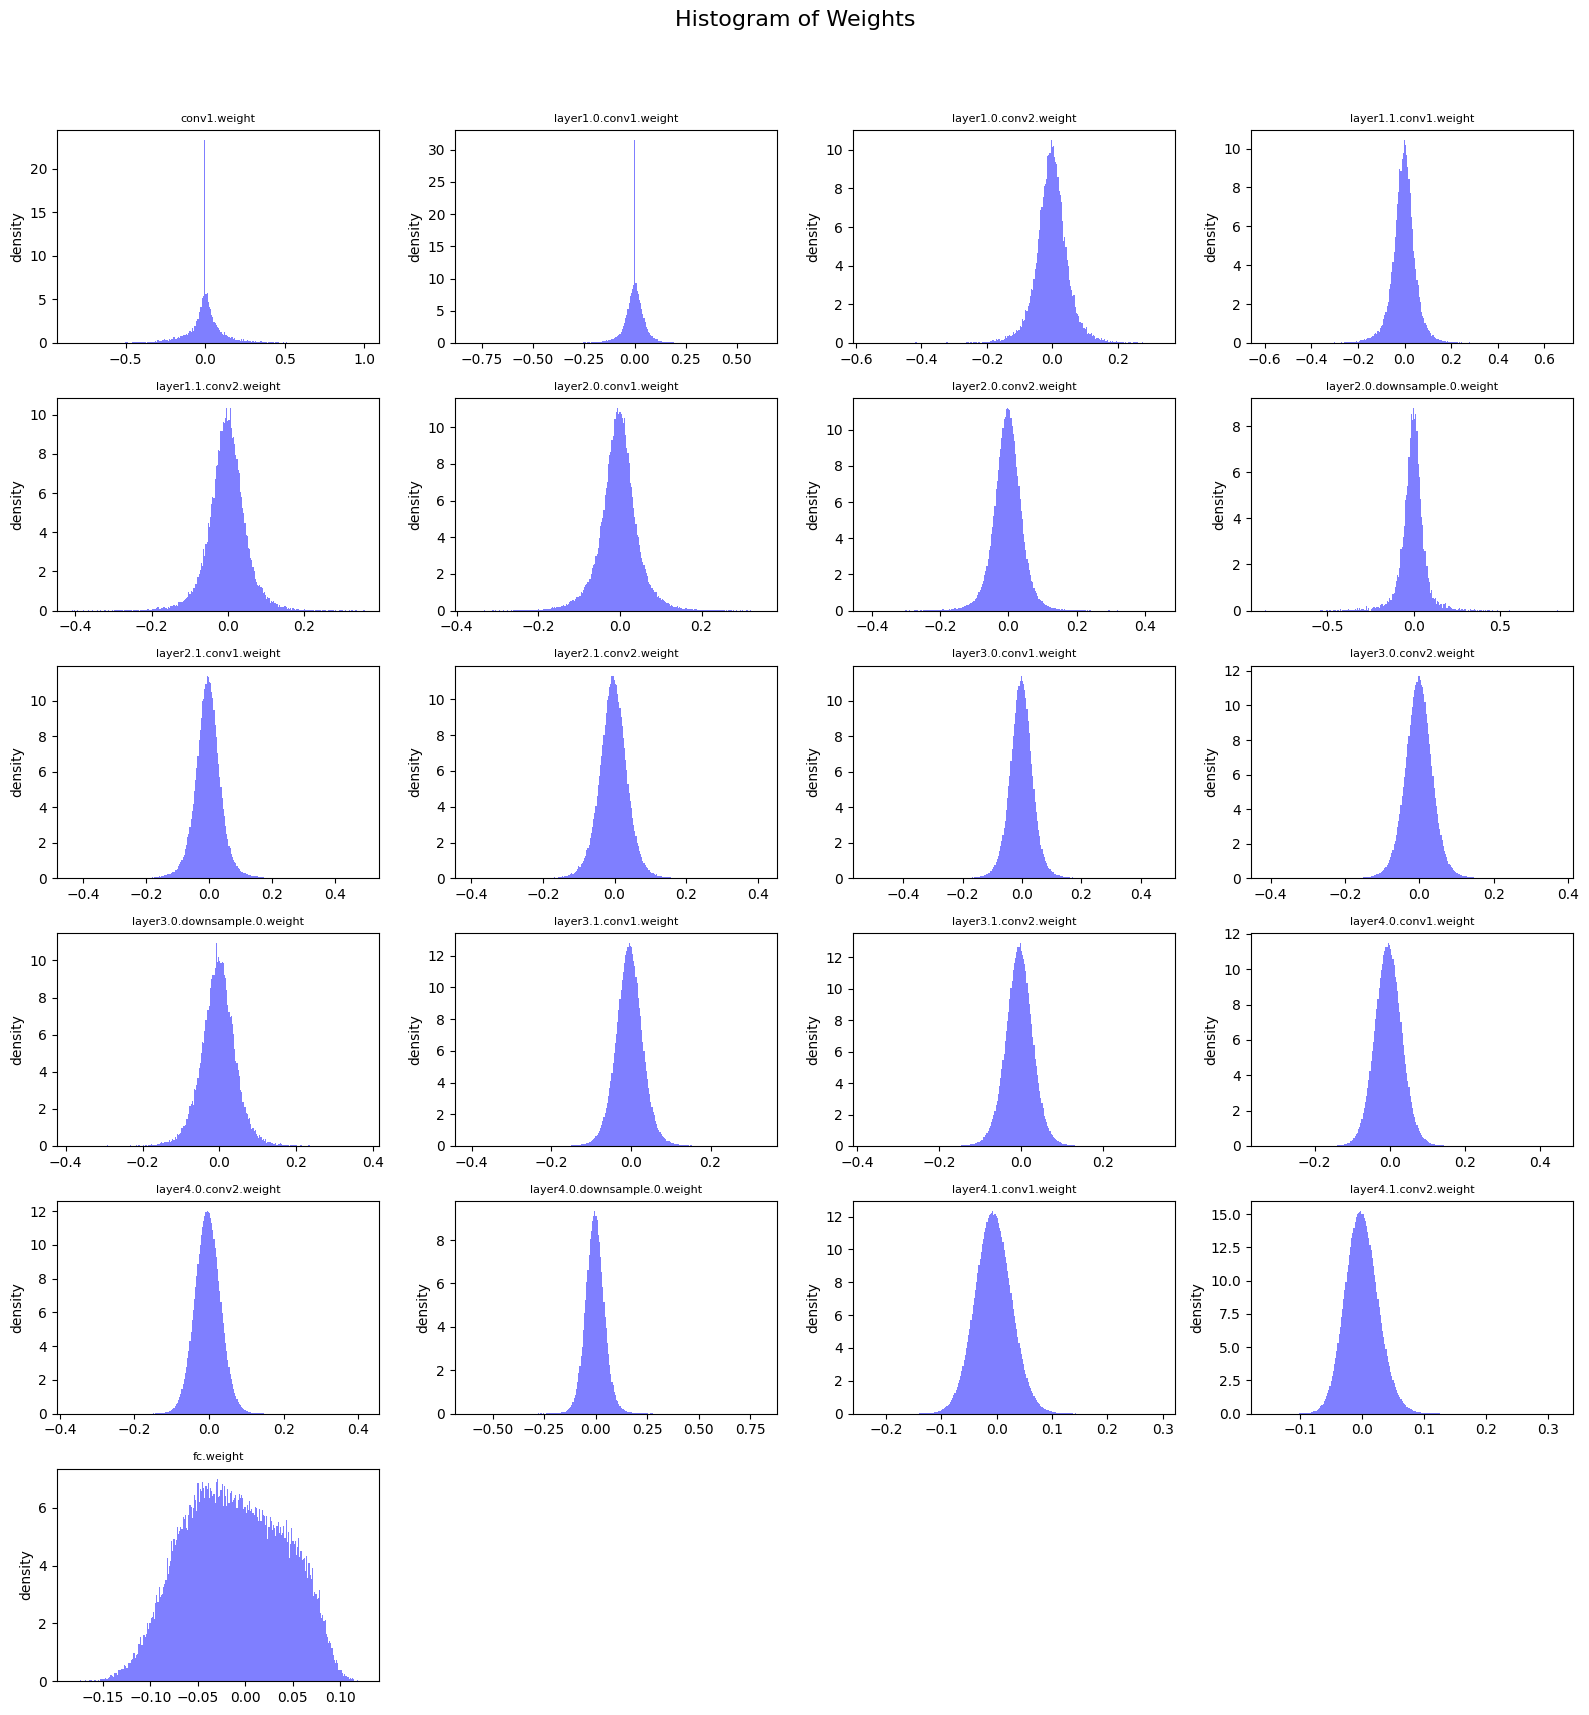

In [21]:
def plot_weight_distribution(model, bins=256, count_nonzero_only=False):
    # Filter parameters with dim > 1 (weights, not biases)
    params_to_plot = [(name, p) for name, p in model.named_parameters() if p.dim() > 1]
    num_params = len(params_to_plot)

    # Calculate grid size
    cols = 4
    rows = math.ceil(num_params / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.ravel()

    for i, (name, param) in enumerate(params_to_plot):
        ax = axes[i]
        param_cpu = param.detach().view(-1).cpu()
        if count_nonzero_only:
            param_cpu = param_cpu[param_cpu != 0]

        ax.hist(param_cpu.numpy(), bins=bins, density=True, color='blue', alpha=0.5)
        ax.set_title(name, fontsize=8)
        ax.set_ylabel('density')

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Histogram of Weights', fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_weight_distribution(model)

In [22]:
def fine_grained_prune(tensor: torch.Tensor, target_sparsity: float):
    """
    Prune the smallest-magnitude weights in 'tensor' to reach target_sparsity.
    Returns a boolean mask where True = keep, False = prune.
    Pruning is done in-place on the tensor.
    """
    assert 0 <= target_sparsity <= 1, "target_sparsity must be in [0, 1]"

    # Special cases
    if target_sparsity == 0:
        return torch.ones_like(tensor, dtype=torch.bool)
    if target_sparsity == 1:
        mask = torch.zeros_like(tensor, dtype=torch.bool)
        tensor.mul_(mask)
        return mask

    num_elements = tensor.numel()
    num_zeros = int(round(target_sparsity * num_elements))
    num_nonzeros = num_elements - num_zeros

    # Flatten absolute values
    flat = tensor.abs().view(-1)

    # Keep the largest 'num_nonzeros' weights
    if num_nonzeros <= 0:
        threshold = float("inf")
    else:
        topk_vals, _ = torch.topk(flat, k=num_nonzeros, largest=True, sorted=True)
        threshold = topk_vals[-1]

    # Build mask and prune in-place
    mask = (tensor.abs() >= threshold)

    # In rare tie cases, mask may keep slightly too many values.
    # Fix that so sparsity is exact.
    current_nonzeros = mask.sum().item()
    if current_nonzeros > num_nonzeros:
        extra = current_nonzeros - num_nonzeros
        tied_positions = ((tensor.abs() == threshold) & mask).view(-1).nonzero(as_tuple=False).view(-1)
        if extra > 0 and len(tied_positions) > 0:
            mask_flat = mask.view(-1)
            mask_flat[tied_positions[:extra]] = False
            mask = mask_flat.view_as(tensor)

    tensor.mul_(mask)
    return mask

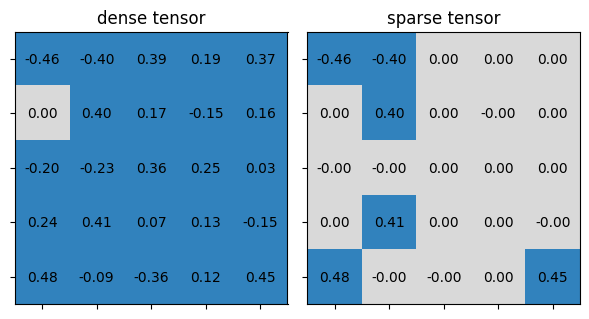

* Test fine_grained_prune()
    target sparsity: 0.75
        sparsity before pruning: 0.04
        sparsity after pruning: 0.76
        sparsity of pruning mask: 0.76
* Test passed.


In [23]:
test_fine_grained_prune()

In [24]:
dense_state_dict = copy.deepcopy(model.state_dict())

In [25]:
@torch.inference_mode()
def get_model_macs_for_dataset(model, dataloader):
    model.eval()
    inputs, _ = next(iter(dataloader))
    inputs = inputs.cuda()
    return get_model_macs(model, inputs)

dense_model_accuracy = evaluate(model, dataloader['test'])
dense_model_sparsity = get_model_sparsity(model)
dense_model_size = get_model_size(model)
dense_model_macs = get_model_macs_for_dataset(model, dataloader['test'])

print(f"Dense model accuracy: {dense_model_accuracy:.2f}%")
print(f"Dense model sparsity: {dense_model_sparsity:.4f}")
print(f"Dense model size: {dense_model_size / MiB:.2f} MiB")
print(f"Dense model MACs: {dense_model_macs / 1e6:.2f} M")

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Dense model accuracy: 81.89%
Dense model sparsity: 0.0000
Dense model size: 42.83 MiB
Dense model MACs: 232460.39 M


In [26]:
def prune_model(model: nn.Module, target_sparsity: float):
    """
    Apply fine-grained pruning to all weight tensors in the model.
    Returns a dict of masks.
    """
    masks = {}

    for name, param in model.named_parameters():
        if param.dim() > 1:  # prune weights only, not biases / BN params
            masks[name] = fine_grained_prune(param.data, target_sparsity)

    return masks

In [27]:
sparsity_levels = [0.0, 0.5, 0.7, 0.8, 0.9, 0.95]
results = []

for sparsity in sparsity_levels:
    # Restore trained dense model
    model.load_state_dict(copy.deepcopy(dense_state_dict))

    # Apply pruning
    masks = prune_model(model, sparsity)

    # Evaluate
    acc = evaluate(model, dataloader['test'], verbose=False)
    model_sparsity = get_model_sparsity(model)
    model_size = get_model_size(model, count_nonzero_only=True)
    model_macs = get_model_macs_for_dataset(model, dataloader['test'])

    results.append({
        "target_sparsity": sparsity,
        "actual_sparsity": model_sparsity,
        "accuracy": acc,
        "size_mib_nonzero_only": model_size / MiB,
        "macs_million": model_macs / 1e6,
    })

    print(
        f"Sparsity target={sparsity:.2f} | "
        f"actual={model_sparsity:.4f} | "
        f"acc={acc:.2f}% | "
        f"size={model_size / MiB:.2f} MiB | "
        f"MACs={model_macs / 1e6:.2f} M"
    )

Sparsity target=0.00 | actual=0.0000 | acc=81.89% | size=42.83 MiB | MACs=232460.39 M
Sparsity target=0.50 | actual=0.4996 | acc=77.30% | size=21.43 MiB | MACs=232460.39 M
Sparsity target=0.70 | actual=0.6994 | acc=29.47% | size=12.88 MiB | MACs=232460.39 M
Sparsity target=0.80 | actual=0.7993 | acc=3.82% | size=8.60 MiB | MACs=232460.39 M
Sparsity target=0.90 | actual=0.8992 | acc=1.23% | size=4.32 MiB | MACs=232460.39 M
Sparsity target=0.95 | actual=0.9492 | acc=1.00% | size=2.18 MiB | MACs=232460.39 M


In [28]:
for row in results:
    print(row)

{'target_sparsity': 0.0, 'actual_sparsity': 0.0, 'accuracy': 81.88999938964844, 'size_mib_nonzero_only': tensor(42.8307, device='cuda:0'), 'macs_million': 232460.386304}
{'target_sparsity': 0.5, 'actual_sparsity': 0.4995680369425495, 'accuracy': 77.30000305175781, 'size_mib_nonzero_only': tensor(21.4339, device='cuda:0'), 'macs_million': 232460.386304}
{'target_sparsity': 0.7, 'actual_sparsity': 0.699395305158298, 'accuracy': 29.469999313354492, 'size_mib_nonzero_only': tensor(12.8751, device='cuda:0'), 'macs_million': 232460.386304}
{'target_sparsity': 0.8, 'actual_sparsity': 0.7993088056693504, 'accuracy': 3.819999933242798, 'size_mib_nonzero_only': tensor(8.5957, device='cuda:0'), 'macs_million': 232460.386304}
{'target_sparsity': 0.9, 'actual_sparsity': 0.8992224843094986, 'accuracy': 1.2300000190734863, 'size_mib_nonzero_only': tensor(4.3164, device='cuda:0'), 'macs_million': 232460.386304}
{'target_sparsity': 0.95, 'actual_sparsity': 0.9491793236295727, 'accuracy': 1.0, 'size_mib

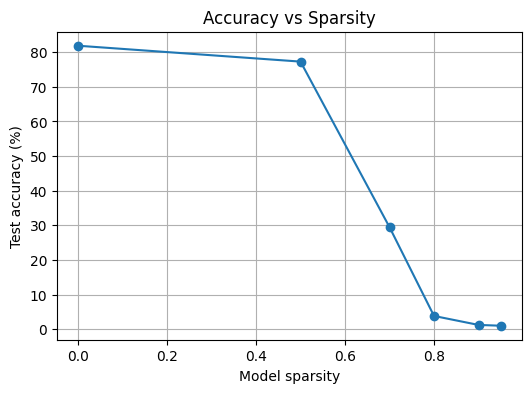

In [29]:
import matplotlib.pyplot as plt

x = [r["actual_sparsity"] for r in results]
y = [r["accuracy"] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(x, y, marker='o')
plt.xlabel("Model sparsity")
plt.ylabel("Test accuracy (%)")
plt.title("Accuracy vs Sparsity")
plt.grid(True)
plt.show()

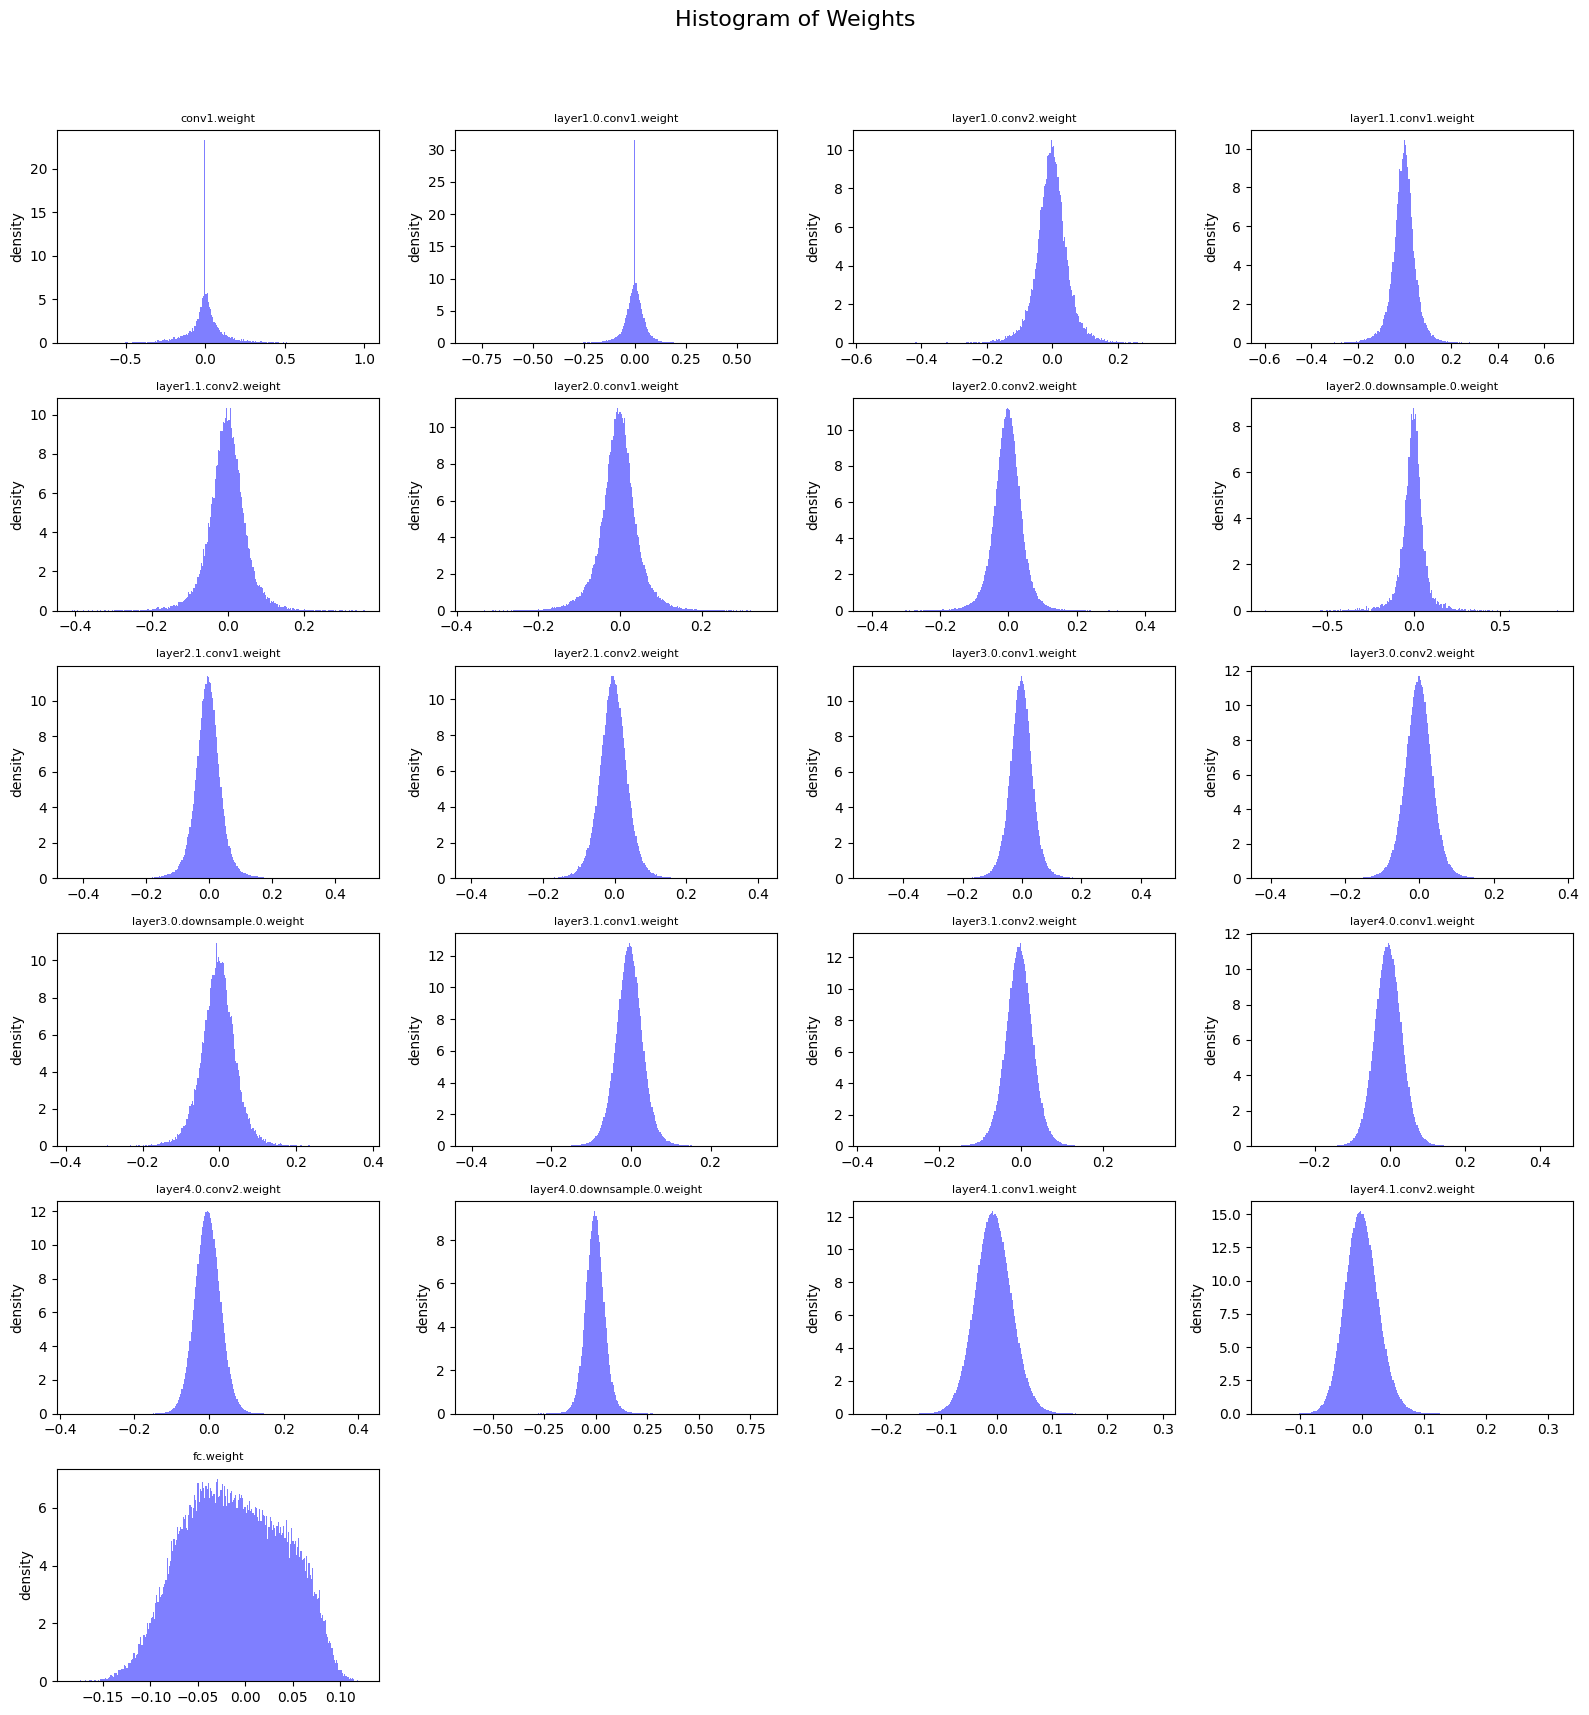

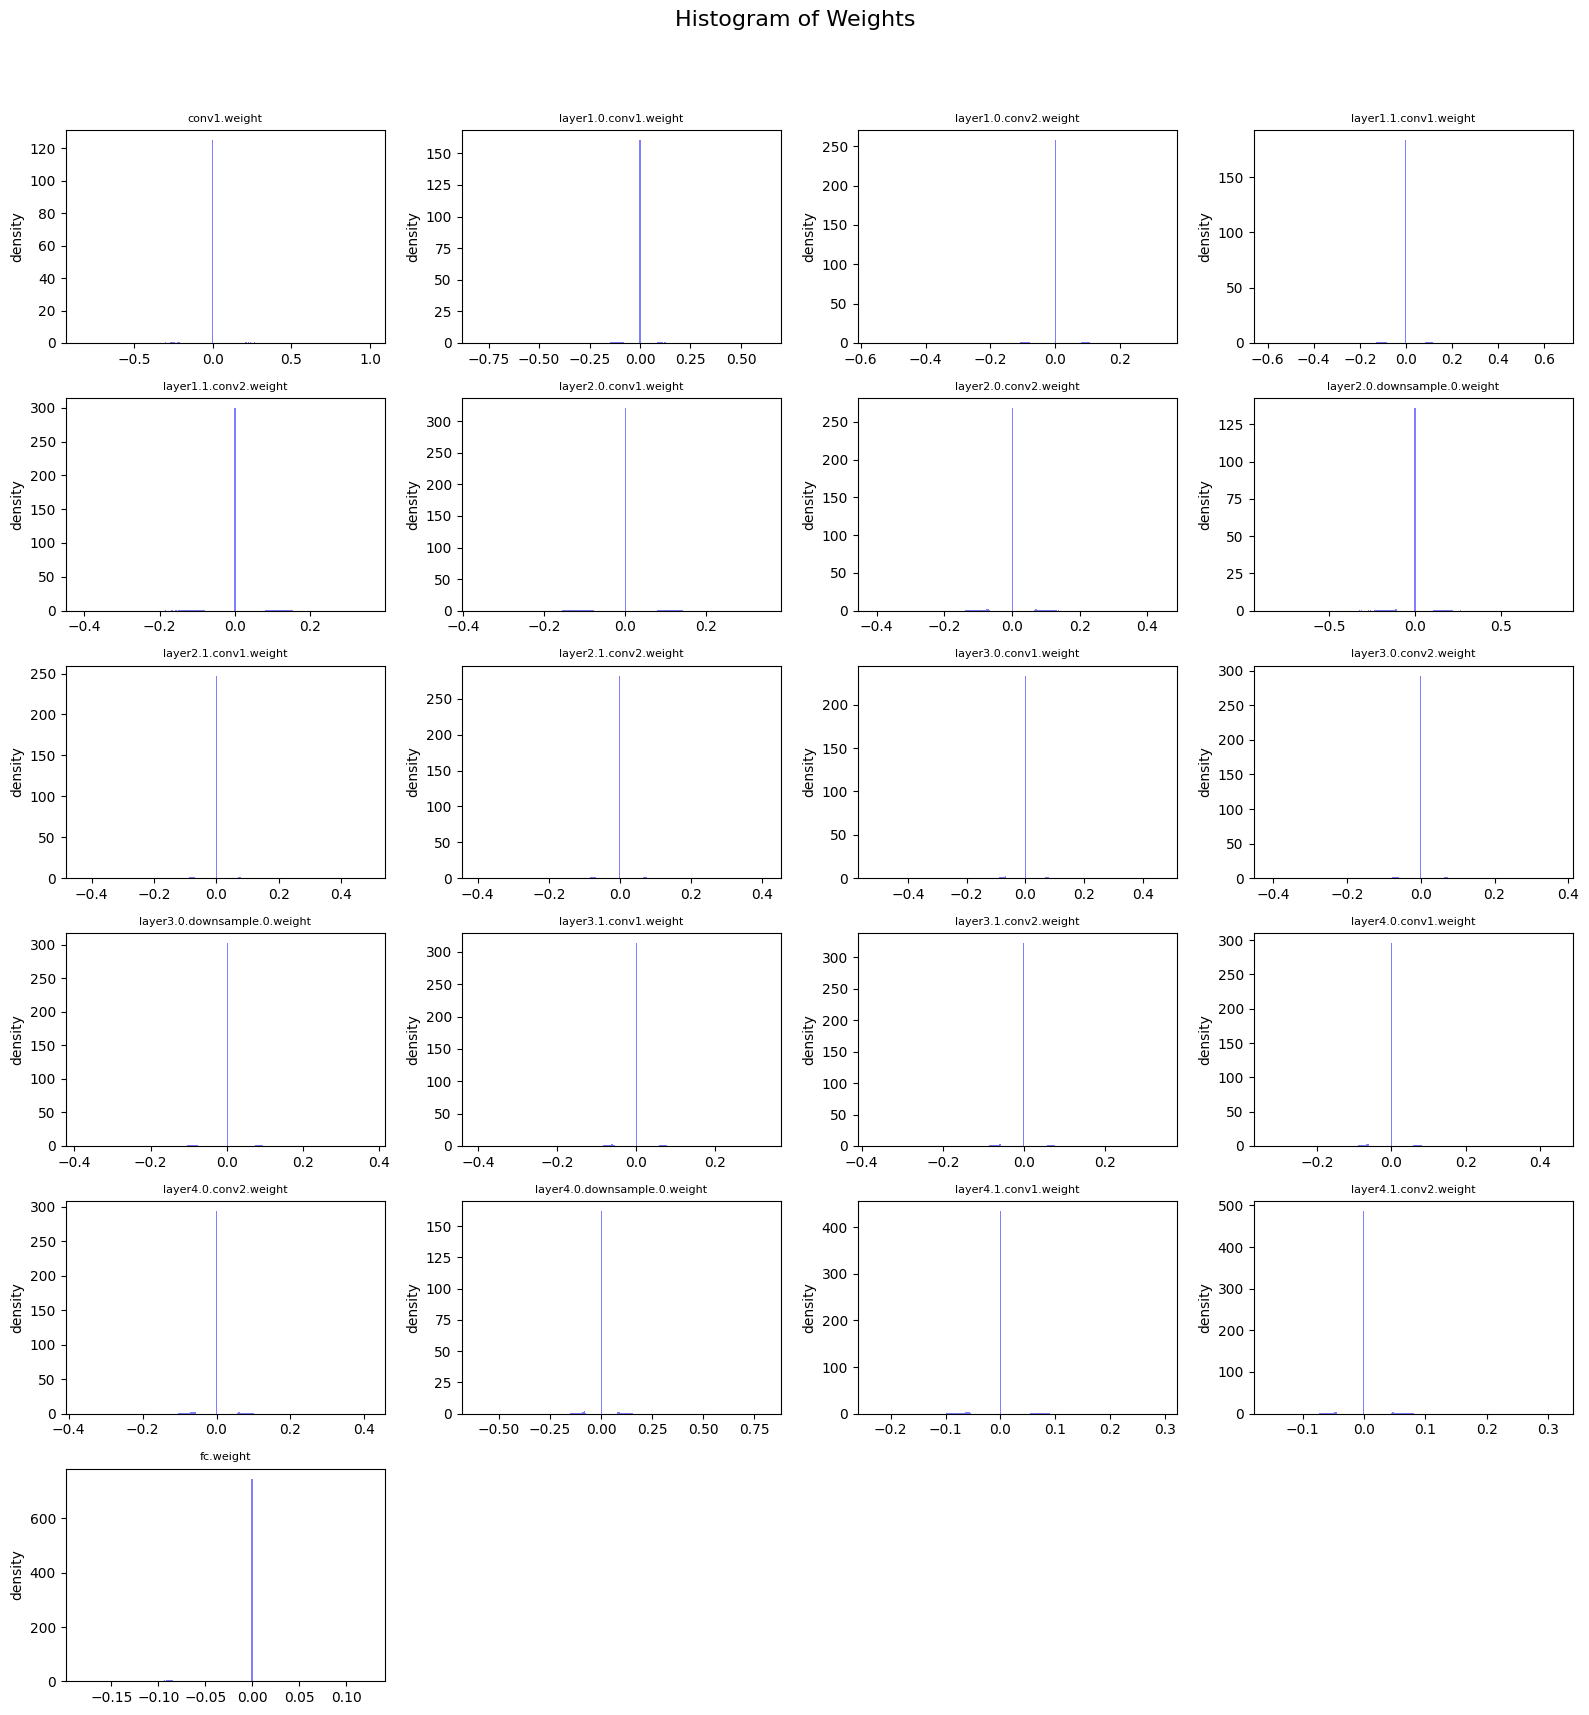

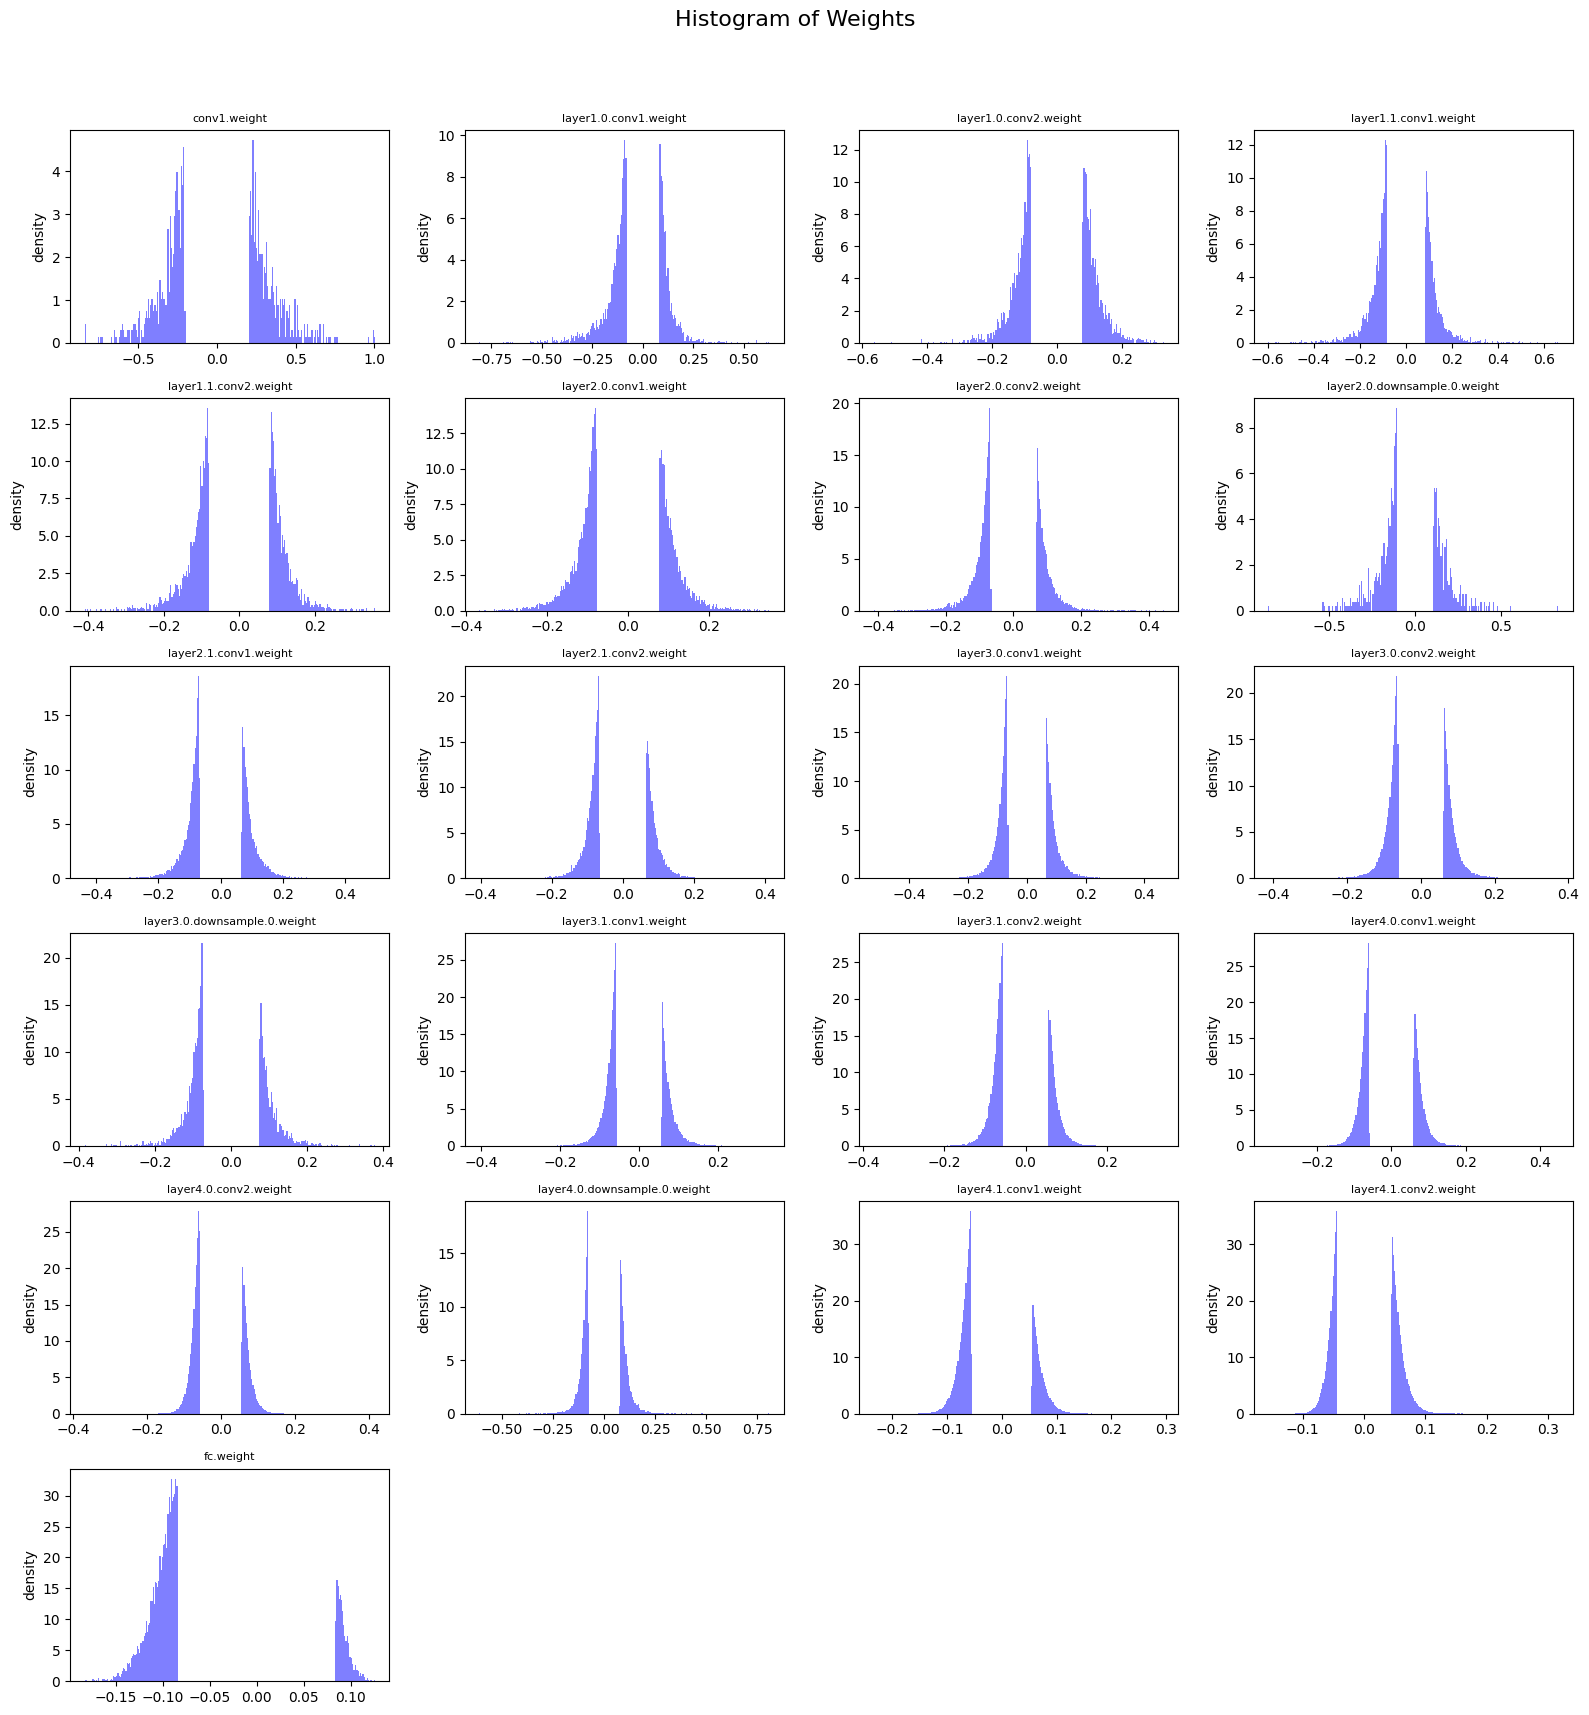

In [30]:
# Before pruning
model.load_state_dict(copy.deepcopy(dense_state_dict))
plot_weight_distribution(model)

# After pruning, for example 90%
model.load_state_dict(copy.deepcopy(dense_state_dict))
_ = prune_model(model, 0.9)
plot_weight_distribution(model)
plot_weight_distribution(model, count_nonzero_only=True)

In [31]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler=None):
    model.train()
    for inputs, targets in tqdm(dataloader, desc="finetune", leave=False):
        inputs = inputs.cuda()
        targets = targets.cuda()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

In [32]:
import copy
import torch
from torch import nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR

# compute how many channels to keep after pruning based on the ratio specified
def get_num_channels_to_keep(channels: int, prune_ratio: float) -> int:
    prune_ratio = max(0.0, min(1.0, prune_ratio))
    keep = int(round(channels * (1.0 - prune_ratio)))
    return max(1, keep)


# collect BasicBlocks modules so we can apply pruning to each layer
def get_basicblocks(model: nn.Module):
    blocks = []
    for layer_name in ['layer1', 'layer2', 'layer3', 'layer4']:
        layer = getattr(model, layer_name)
        for block in layer:
            if isinstance(block, BasicBlock):
                blocks.append(block)
    return blocks

# compute the importance of each channel for conv layer,
def get_input_channel_importance(weight: torch.Tensor) -> torch.Tensor:
    # weight shape for conv2: [out_channels, in_channels, kH, kW]
    importances = []
    for c in range(weight.shape[1]):
        channel_weight = weight[:, c, :, :]
        importance = torch.norm(channel_weight, p=2)
        importances.append(importance.view(1))
    return torch.cat(importances, dim=0)

In [33]:
@torch.no_grad()
def apply_channel_sorting_resnet(model: nn.Module) -> nn.Module:
    model = copy.deepcopy(model)
    blocks = get_basicblocks(model)

    for block in blocks:
        importance = get_input_channel_importance(block.conv2.weight)
        sort_idx = torch.argsort(importance, descending=True)

        # conv1 output channels
        block.conv1.weight.copy_(
            torch.index_select(block.conv1.weight.detach(), 0, sort_idx)
        )

        # bn1 parameters/buffers
        for tensor_name in ['weight', 'bias', 'running_mean', 'running_var']:
            tensor = getattr(block.bn1, tensor_name)
            tensor.copy_(torch.index_select(tensor.detach(), 0, sort_idx))

        # conv2 input channels
        block.conv2.weight.copy_(
            torch.index_select(block.conv2.weight.detach(), 1, sort_idx)
        )

    return model

In [34]:
@torch.no_grad()
def channel_prune_resnet(model: nn.Module, prune_ratio=0.3) -> nn.Module:
    """
    Prunes internal channels inside each BasicBlock:
      conv1.out_channels
      bn1
      conv2.in_channels

    This preserves block output shape, so residual addition still works.
    """
    assert isinstance(prune_ratio, (float, list))

    model = copy.deepcopy(model)
    blocks = get_basicblocks(model)

    if isinstance(prune_ratio, float):
        prune_ratio = [prune_ratio] * len(blocks)
    else:
        assert len(prune_ratio) == len(blocks), \
            f"Expected {len(blocks)} prune ratios, got {len(prune_ratio)}"

    for block, p_ratio in zip(blocks, prune_ratio):
        original_channels = block.conv1.out_channels
        n_keep = get_num_channels_to_keep(original_channels, p_ratio)

        # keep first n_keep channels
        block.conv1.weight.set_(block.conv1.weight.detach()[:n_keep, :, :, :])

        block.bn1.weight.set_(block.bn1.weight.detach()[:n_keep])
        block.bn1.bias.set_(block.bn1.bias.detach()[:n_keep])
        block.bn1.running_mean.set_(block.bn1.running_mean.detach()[:n_keep])
        block.bn1.running_var.set_(block.bn1.running_var.detach()[:n_keep])

        block.conv2.weight.set_(block.conv2.weight.detach()[:, :n_keep, :, :])

        # update metadata so forward uses correct shapes
        block.conv1.out_channels = n_keep
        block.bn1.num_features = n_keep
        block.conv2.in_channels = n_keep

    return model

In [35]:
def finetune_model(
    model: nn.Module,
    train_loader,
    test_loader,
    device='cuda',
    num_epochs=5,
    lr=0.01,
    weight_decay=1e-4
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        scheduler.step()

        acc = evaluate(model, test_loader, verbose=False)
        if acc > best_acc:
            best_acc = acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} - acc={acc:.2f}% - best={best_acc:.2f}%")

    model.load_state_dict(best_state)
    return model, best_acc

In [36]:
pruned_model = channel_prune_resnet(model, prune_ratio=0.3)
acc_before = evaluate(pruned_model, dataloader['test'])
print(f"Pruned accuracy before finetuning: {acc_before:.2f}%")

pruned_model, best_acc = finetune_model(
    pruned_model,
    dataloader['train'],
    dataloader['test'],
    device='cuda',
    num_epochs=5,
    lr=0.01
)
print(f"Best accuracy after finetuning: {best_acc:.2f}%")

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Pruned accuracy before finetuning: 1.01%
Epoch 1/5 - acc=72.84% - best=72.84%
Epoch 2/5 - acc=74.81% - best=74.81%
Epoch 3/5 - acc=77.29% - best=77.29%
Epoch 4/5 - acc=78.48% - best=78.48%
Epoch 5/5 - acc=79.25% - best=79.25%
Best accuracy after finetuning: 79.25%


In [37]:
def make_pruning_callback(model, masks):
    name_to_param = dict(model.named_parameters())

    def callback():
        for name, mask in masks.items():
            name_to_param[name].data.mul_(mask)

    return callback

In [38]:
import copy
import torch
import torch.optim as optim
from torch import nn

def finetune_after_pruning(
    model,
    dense_state_dict,
    dataloader,
    target_sparsity=0.7,
    num_epochs=5,
    lr=1e-5,
    weight_decay=1e-2,
):
    # 1) Restore dense trained model
    model.load_state_dict(copy.deepcopy(dense_state_dict))

    # 2) Apply pruning
    masks = prune_model(model, target_sparsity)

    # 3) Evaluate right after pruning
    pruned_acc = evaluate(model, dataloader['test'], verbose=False)
    pruned_sparsity = get_model_sparsity(model)
    pruned_size = get_model_size(model, count_nonzero_only=True)

    print(f"After pruning:")
    print(f"  target sparsity = {target_sparsity:.2f}")
    print(f"  actual sparsity = {pruned_sparsity:.4f}")
    print(f"  test accuracy   = {pruned_acc:.2f}%")
    print(f"  model size      = {pruned_size / MiB:.2f} MiB")

    # 4) Setup fine-tuning
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # simple scheduler
    scheduler = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=1)

    # callback that re-applies mask after each optimizer step
    prune_callback = make_pruning_callback(model, masks)

    # 5) Fine-tune
    history = []
    print("\nFine-tuning pruned model...")
    for epoch in range(num_epochs):
        train(
            model,
            dataloader['train'],
            criterion,
            optimizer,
            scheduler,
            callbacks=[prune_callback]
        )

        test_acc = evaluate(model, dataloader['test'], verbose=False)
        model_sparsity = get_model_sparsity(model)

        history.append({
            "epoch": epoch + 1,
            "accuracy": test_acc,
            "sparsity": model_sparsity,
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"accuracy = {test_acc:.2f}% | "
            f"sparsity = {model_sparsity:.4f}"
        )

    return masks, history

In [39]:
masks_70, history_70 = finetune_after_pruning(
    model=model,
    dense_state_dict=dense_state_dict,
    dataloader=dataloader,
    target_sparsity=0.5,
    num_epochs=5,
    lr=1e-5,
    weight_decay=1e-2,
)

After pruning:
  target sparsity = 0.50
  actual sparsity = 0.4996
  test accuracy   = 77.30%
  model size      = 21.43 MiB

Fine-tuning pruned model...


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/5 | accuracy = 81.33% | sparsity = 0.4996


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/5 | accuracy = 81.41% | sparsity = 0.4996


...

Epoch 3/5 | accuracy = 81.50% | sparsity = 0.4996


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 4/5 | accuracy = 81.43% | sparsity = 0.4996


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 5/5 | accuracy = 81.62% | sparsity = 0.4996


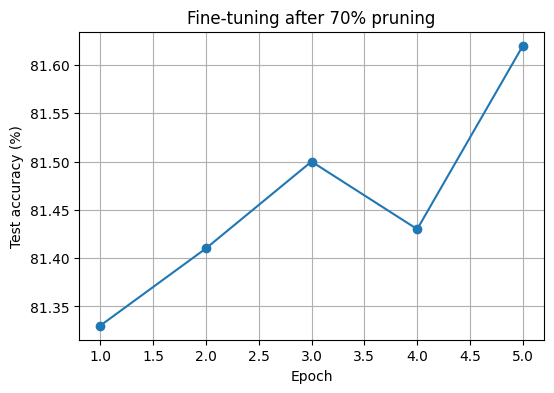

In [40]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history_70]
accs = [h["accuracy"] for h in history_70]

plt.figure(figsize=(6, 4))
plt.plot(epochs, accs, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Fine-tuning after 70% pruning")
plt.grid(True)
plt.show()

In [41]:
finetune_results = {}

for sparsity in [0.5, 0.7, 0.8]:
    print("\n" + "="*60)
    print(f"Running fine-tuning for sparsity = {sparsity:.2f}")

    masks, history = finetune_after_pruning(
        model=model,
        dense_state_dict=dense_state_dict,
        dataloader=dataloader,
        target_sparsity=sparsity,
        num_epochs=5,
        lr=1e-5,
        weight_decay=1e-2,
    )

    finetune_results[sparsity] = history


Running fine-tuning for sparsity = 0.50
After pruning:
  target sparsity = 0.50
  actual sparsity = 0.4996
  test accuracy   = 77.30%
  model size      = 21.43 MiB

Fine-tuning pruned model...


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/5 | accuracy = 81.32% | sparsity = 0.4996


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/5 | accuracy = 81.40% | sparsity = 0.4996


...

Epoch 3/5 | accuracy = 77.22% | sparsity = 0.7993


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 4/5 | accuracy = 78.12% | sparsity = 0.7993


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 5/5 | accuracy = 78.46% | sparsity = 0.7993


In [42]:
def make_pruning_callback(model, masks):
    name_to_param = dict(model.named_parameters())
    def callback():
        for name, mask in masks.items():
            name_to_param[name].data.mul_(mask)
    return callback

model.load_state_dict(copy.deepcopy(dense_state_dict))
masks = prune_model(model, 0.7)

print("Accuracy right after pruning:", evaluate(model, dataloader['test'], verbose=False))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=1)
prune_callback = make_pruning_callback(model, masks)

for epoch in range(5):
    train(
        model,
        dataloader['train'],
        criterion,
        optimizer,
        scheduler,
        callbacks=[prune_callback]
    )
    acc = evaluate(model, dataloader['test'], verbose=False)
    print(f"Epoch {epoch+1}: {acc:.2f}%")

Accuracy right after pruning: 29.469999313354492


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1: 79.27%


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2: 80.04%


...

Epoch 3: 80.14%


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 4: 80.49%


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 5: 80.47%



Running experiment for sparsity = 0.85

After pruning to 0.85:
  actual sparsity = 0.8493
  test accuracy   = 1.45%
  model size      = 6.46 MiB


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | acc = 61.78% | sparsity = 0.8493


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/10 | acc = 68.04% | sparsity = 0.8493


...

Epoch 8/10 | acc = 27.06% | sparsity = 0.9492


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | acc = 29.27% | sparsity = 0.9492


train:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | acc = 31.16% | sparsity = 0.9492

SUMMARY
Sparsity 0.85 | initial acc = 1.45% | best acc = 76.99% | final acc = 76.99%
Sparsity 0.90 | initial acc = 1.23% | best acc = 67.97% | final acc = 67.97%
Sparsity 0.95 | initial acc = 1.00% | best acc = 31.16% | final acc = 31.16%


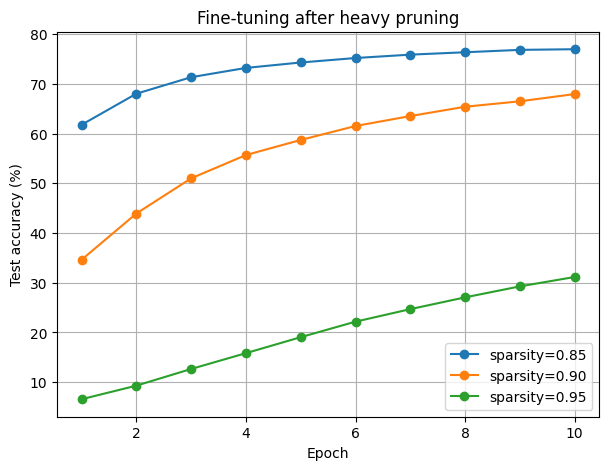

In [43]:
import copy
import torch
import torch.optim as optim
from torch import nn
import matplotlib.pyplot as plt

# Re-apply pruning mask after every optimizer step
def make_pruning_callback(model, masks):
    name_to_param = dict(model.named_parameters())

    def callback():
        for name, mask in masks.items():
            name_to_param[name].data.mul_(mask)

    return callback

# Fine-tune one pruned model and store history
def finetune_after_pruning(
    model,
    dense_state_dict,
    dataloader,
    target_sparsity=0.9,
    num_epochs=5,
    lr=1e-5,
    weight_decay=1e-2,
):
    # Restore dense trained model
    model.load_state_dict(copy.deepcopy(dense_state_dict))

    # Apply pruning
    masks = prune_model(model, target_sparsity)

    # Evaluate immediately after pruning
    pruned_acc = evaluate(model, dataloader['test'], verbose=False)
    pruned_sparsity = get_model_sparsity(model)
    pruned_size = get_model_size(model, count_nonzero_only=True)

    print(f"\nAfter pruning to {target_sparsity:.2f}:")
    print(f"  actual sparsity = {pruned_sparsity:.4f}")
    print(f"  test accuracy   = {pruned_acc:.2f}%")
    print(f"  model size      = {pruned_size / MiB:.2f} MiB")

    # Fine-tuning setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=1)

    prune_callback = make_pruning_callback(model, masks)

    # Fine-tune and track accuracy
    history = []
    best_acc = pruned_acc

    for epoch in range(num_epochs):
        train(
            model,
            dataloader['train'],
            criterion,
            optimizer,
            scheduler,
            callbacks=[prune_callback]
        )

        acc = evaluate(model, dataloader['test'], verbose=False)
        sparsity = get_model_sparsity(model)
        best_acc = max(best_acc, acc)

        history.append({
            "epoch": epoch + 1,
            "accuracy": acc,
            "sparsity": sparsity,
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"acc = {acc:.2f}% | "
            f"sparsity = {sparsity:.4f}"
        )

    return {
        "target_sparsity": target_sparsity,
        "initial_accuracy": pruned_acc,
        "best_accuracy": best_acc,
        "final_accuracy": history[-1]["accuracy"],
        "history": history,
    }

# Run comparison for 90% and 95%
compare_results = {}

for sparsity in [.85, .90, 0.95]:
    print("\n" + "=" * 70)
    print(f"Running experiment for sparsity = {sparsity:.2f}")

    result = finetune_after_pruning(
        model=model,
        dense_state_dict=dense_state_dict,
        dataloader=dataloader,
        target_sparsity=sparsity,
        num_epochs=10,      # try 10; increase if needed
        lr=1e-5,            # if recovery is weak, also try 5e-5 or 1e-4
        weight_decay=1e-2,
    )

    compare_results[sparsity] = result

# Print summary
print("\n" + "=" * 70)
print("SUMMARY")
for sparsity, result in compare_results.items():
    print(
        f"Sparsity {sparsity:.2f} | "
        f"initial acc = {result['initial_accuracy']:.2f}% | "
        f"best acc = {result['best_accuracy']:.2f}% | "
        f"final acc = {result['final_accuracy']:.2f}%"
    )

# Plot recovery curves
plt.figure(figsize=(7, 5))
for sparsity, result in compare_results.items():
    epochs = [h["epoch"] for h in result["history"]]
    accs = [h["accuracy"] for h in result["history"]]
    plt.plot(epochs, accs, marker='o', label=f"sparsity={sparsity:.2f}")

plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Fine-tuning after heavy pruning")
plt.grid(True)
plt.legend()
plt.show()